# Stage modélisation système Hamiltonien 
## Première approche


On pose $p := (p_x , p_y)$ le momentum à la croisé d'un champ éléctrique et magnétique. La variation du momentum s'écrit: 
$$
\begin{equation}
\frac{dp}{dt} = eE + \frac{e}{c} \left[\frac{\partial \varepsilon (p)}{\partial p}, \ B\right] 
\end{equation}
\tag{1}
$$
Où :
- $e$ est la charge de l'électron
- $E$ est le champ électrique
- $c$ la vitesse de la lumière (prendre 1)
- $\varepsilon(p)$ est la bande de dispersion tel que $\varepsilon(p) = \sqrt{M^2 + v_F^2 p^2}$ (Bande dispersion of massive Dirac fermions)
- $B$ le champ magnétique

Le problème (1) peut se réécrire sous la forme des équations Hamiltonienne suivante:
$$
\begin{equation}
    \begin{cases}
    \dfrac{dp_x}{dt} = \dfrac{\partial \mathcal{H}}{\partial p_y} \\
    \dfrac{dp_y}{dt} = -\dfrac{\partial \mathcal{H}}{\partial p_x}
    \end{cases}
\end{equation}
\tag{2}
$$
Avec $\mathcal{H}(p_x, \ p_y) := \dfrac{eB}{c} \mathcal{W} = \dfrac{eB}{c} \left[\varepsilon(p) + v_d p_y \right] $
et où l'on note $\mathcal{W}$ l'énergie totale et $v_d$ le "drift velocity" de sorte que $v_d = \dfrac{cE}{B}$.

Étudions $\mathscr{H} : t \longmapsto \mathcal{H}(p_x, \ p_y)$
$$ 
\begin{align*}
\dfrac{d\mathscr{H}}{dt} &= \dfrac{\partial \mathcal{H}}{\partial p_x}\dfrac{ dp_x}{dt} + \dfrac{\partial \mathcal{H}}{\partial p_y}\dfrac{ dp_y}{dt} \\
                         &\overset{(2)}{=} \dfrac{\partial \mathcal{H}}{\partial p_x} \dfrac{\partial \mathcal{H}}{\partial p_y} - \dfrac{\partial \mathcal{H}}{\partial p_y} \dfrac{\partial \mathcal{H}}{\partial p_x} \\ 
                         &= 0
\end{align*}
$$

Donc l'Hamiltonien ne vari pas au cours du temps.
Etudions le comportement à l'aide de quelques schémas pour que l'on puisse se faire une idée.

### Schéma Euler Explicite

En partant de (2) on va écrire le schéma explicite:
On calcule $\dfrac{\partial \mathcal{H}}{\partial p_x}$ (resp. $\dfrac{\partial \mathcal{H}}{\partial p_y}$ ) qui vaut $\dfrac{eB v_F^2 p_x}{c\varepsilon(p)}$ (resp. $\dfrac{eB}{c} \left( \dfrac{v_F^2 p_y}{\varepsilon(p)}+ v_d\right)$). 

<!-- Le schéma s'écrit (a corriger j'avais fait une erreur): 
$$ P^{n+1} = \left(1 + \dfrac{\Delta t \ e B \ v_F^2}{c\ \varepsilon(p)} \right) \times P^n$$ -->

Pour simplifier, regardons le cas simple où $\mathcal{H}(p_x, \ p_y) = \dfrac{1}{2}\left(p_x^2 + p_y^2\right)$
Alors $\dfrac{\partial \mathcal{H}}{\partial p_x}$ (resp. $\dfrac{\partial \mathcal{H}}{\partial p_y}$ ) vaut $p_x$ (resp. $p_y$)
Le schéma s'écrit : 
$$
\begin{bmatrix}
p_x^{n+1} \\
p_y^{n+1} \\
\end{bmatrix} 
=
\begin{bmatrix}
1 & \Delta t \\
-\Delta t & 1 \\
\end{bmatrix}
\times 
\begin{bmatrix}
p_x^n \\
p_y^n
\end{bmatrix}
$$

In [2]:
# Packages ------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pyhamsys import HamSys, solve_ivp_sympext, Parameters

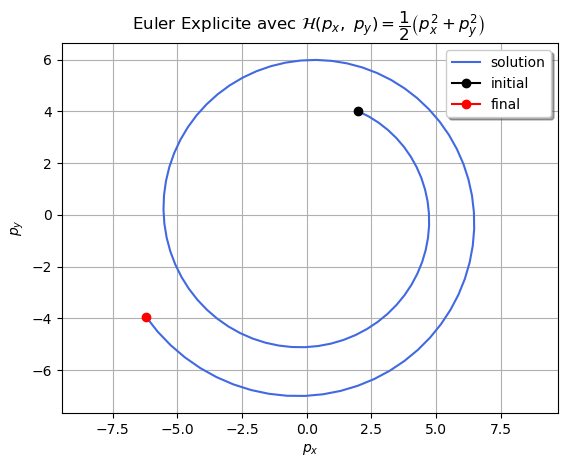

In [26]:
# Euler explicite -----------------------------
def EE_jouet(deltaT, T, P):
    Iteration_matrix = [[1, deltaT], [-deltaT, 1]]
    P_trajectory = [P]
    t = 0
    while ( t + deltaT < T):
        P = Iteration_matrix @ P
        t += deltaT
        P_trajectory.append(P)
    deltaT = T - t
    P = Iteration_matrix @ P
    return np.array(P_trajectory)
# -----------------------------------------------
p_x, p_y = 2, 4
P = np.array([p_x, p_y])
deltaT = 0.1
T = 10
P_trajectory = EE_jouet(deltaT, T, P)

plt.plot(P_trajectory[:, 0], P_trajectory[:,1], color='royalblue',label='solution')
plt.plot(P_trajectory[0,0], P_trajectory[0, 1], color='black', marker='o', label='initial')
plt.plot(P_trajectory[-1,0], P_trajectory[-1, 1], color='red', marker='o', label='final')

plt.legend(shadow=True)
plt.title(r'Euler Explicite avec $\mathcal{H}(p_x, \ p_y) = \dfrac{1}{2}\left(p_x^2 + p_y^2\right)$ ')
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.axis('equal')
plt.grid()
plt.show()

### Euler Implicite
De façon similaire on obtient le schéma implicite:
$$
\begin{align*}
\begin{bmatrix}
1 & -\Delta t \\
\Delta t & 1 \\
\end{bmatrix}
\times 
\begin{bmatrix}
p_x^{n+1} \\
p_y^{n+1} \\
\end{bmatrix} 
&=&
\begin{bmatrix}
p_x^n \\
p_y^n
\end{bmatrix} \\
P^{n+1} &=& \dfrac{1}{1 + (\Delta t)^2} 
\begin{bmatrix}
1 & \Delta t \\
-\Delta t & 1 \\
\end{bmatrix}
 \times P^n
\end{align*}
$$

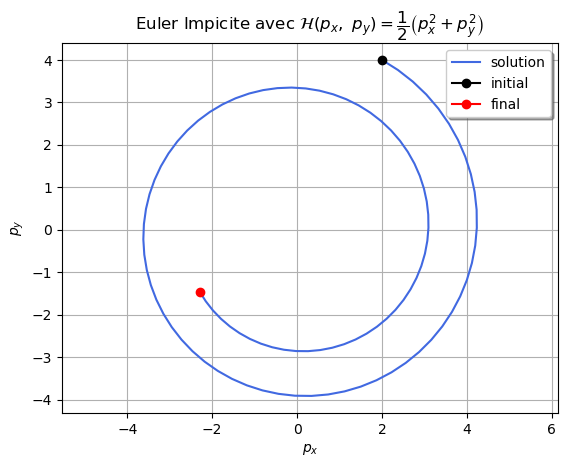

In [25]:
# Euler implicite -----------------------------
def EI_jouet(deltaT, T, P):
    Iteration_matrix = [[1/(1 + deltaT**2), deltaT/(1 + deltaT**2)], [-deltaT/(1 + deltaT**2), 1/(1 + deltaT**2)]]
    P_trajectory = [P]
    t = 0
    while ( t + deltaT < T):
        P = Iteration_matrix @ P
        t += deltaT
        P_trajectory.append(P)
    deltaT = T - t
    P = Iteration_matrix @ P
    return np.array(P_trajectory)
# -----------------------------------------------
p_x, p_y = 2, 4
P = np.array([p_x, p_y])
deltaT = 0.1
T = 10
P_trajectory = EI_jouet(deltaT, T, P)

plt.plot(P_trajectory[:, 0], P_trajectory[:,1], color='royalblue',label='solution')
plt.plot(P_trajectory[0,0], P_trajectory[0, 1], color='black', marker='o', label='initial')
plt.plot(P_trajectory[-1,0], P_trajectory[-1, 1], color='red', marker='o', label='final')

plt.legend(shadow=True)
plt.title(r'Euler Impicite avec $\mathcal{H}(p_x, \ p_y) = \dfrac{1}{2}\left(p_x^2 + p_y^2\right)$ ')
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.axis('equal')
plt.grid()
plt.show()

### Euler Symplectique
On code le schéma suivant:
$$
\begin{cases}
\begin{align*}
x_{n+1} &=& x_n + h \partial_x \mathcal{H}(x_n, y_{n+1}) \\
y_{n+1} &=& y_n + h \partial_y \mathcal{H}(x_n, y_{n+1}) 
\end{align*}
\end{cases}
$$
On repart de notre problème $\mathcal{H}(p_x^n, \ p_y^{n+1}) = \dfrac{1}{2}\left((p_x^{n})^2 + (p_y^{n+1})^2\right)$ avec $\partial_x \mathcal{H} = p_x^n$ et $  \partial_y \mathcal{H} = p_y^{n+1}$. \\
Puisque notre problème vérifie:
$$
\begin{cases}
\begin{align*}
\partial_t p_x &=& \partial_y H \\
\partial_t p_y &=& -\partial_x H
\end{align*}
\end{cases}
$$
On obtient:
$$
\begin{cases}
\begin{align*}
p_x^{n+1} &=p_x^n + \Delta t \times p_y^{n+1} \\ 
p_y^{n+1} &= p_y^n - \Delta t \times p_x^n
\end{align*}
\end{cases} \\
$$
Ce qui se réécrit:
$$
 \begin{bmatrix} 1 & - \Delta t \\ 0 & 1 \end{bmatrix} P^{n+1} = \begin{bmatrix} 1 & 0 \\ - \Delta t & 1 \end{bmatrix} P^n$$
Donc le schéma final est:
$$
P^{n+1} = \begin{bmatrix} 1 -(\Delta t)^2 & \Delta t \\ -\Delta t & 1 \end{bmatrix} \times P^n
$$



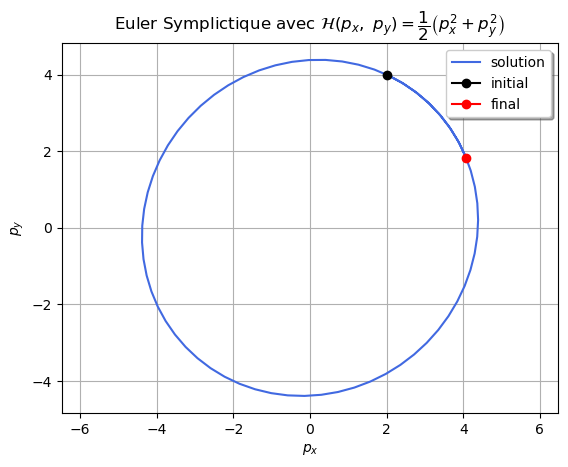

In [24]:
# Euler Symplictique -----------------------------
def ES_jouet(deltaT, T, P):
    Iteration_matrix = [[1 - deltaT**2, deltaT], [-deltaT, 1]]
    P_trajectory = [P]
    t = 0
    while ( t + deltaT < T):
        P = Iteration_matrix @ P
        t += deltaT
        P_trajectory.append(P)
    deltaT = T - t
    P = Iteration_matrix @ P
    return np.array(P_trajectory)
# -----------------------------------------------
p_x, p_y = 2, 4
P = np.array([p_x, p_y])
deltaT = 0.1
T = 7
P_trajectory = ES_jouet(deltaT, T, P)

plt.plot(P_trajectory[:, 0], P_trajectory[:,1], color='royalblue',label='solution')
plt.plot(P_trajectory[0,0], P_trajectory[0, 1], color='black', marker='o', label='initial')
plt.plot(P_trajectory[-1,0], P_trajectory[-1, 1], color='red', marker='o', label='final')

plt.legend(shadow=True)
plt.title(r'Euler Symplictique avec $\mathcal{H}(p_x, \ p_y) = \dfrac{1}{2}\left(p_x^2 + p_y^2\right)$ ')
plt.grid()
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.axis('equal')
plt.show()

### Comparaison des 3 méthodes



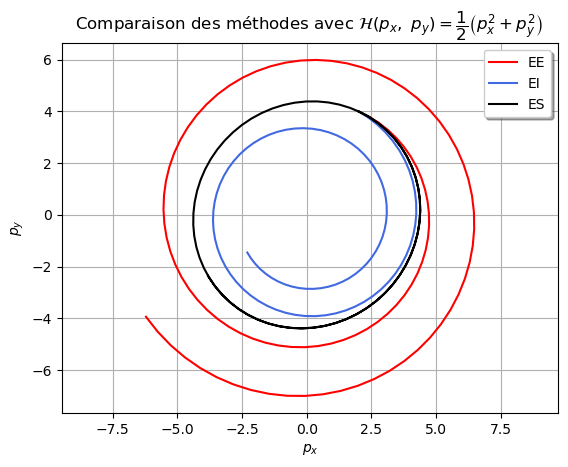

In [27]:
p_x, p_y = 2, 4
P = np.array([p_x, p_y])
deltaT = 0.1
T = 10
#---- Trajectoires selon les méthodes
traj_EX = EE_jouet(deltaT, T, P)
plt.plot(traj_EX[:, 0], traj_EX[:,1], color='red',label='EE')

traj_EI = EI_jouet(deltaT, T, P)
plt.plot(traj_EI[:, 0], traj_EI[:,1], color='royalblue',label='EI')

traj_ES = ES_jouet(deltaT, T, P)
plt.plot(traj_ES[:, 0], traj_ES[:,1], color='black',label='ES')

plt.legend(shadow=True)
plt.grid()
plt.title(r'Comparaison des méthodes avec $\mathcal{H}(p_x, \ p_y) = \dfrac{1}{2}\left(p_x^2 + p_y^2\right)$ ')
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.axis('equal')
plt.show()